In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import roc_auc_score
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import math

In [2]:
redwine = pd.read_csv('winequality-red.csv', sep=",")
redwine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
#Q1
redwine['quality'] = np.where(redwine['quality'] > 6.5, 'good', 'bad')
redwine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,bad
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,bad
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,bad
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,bad
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,bad


In [4]:
X=redwine.drop('quality',axis=1)
y=redwine['quality']

In [5]:
xname = X.columns
yname = ['bad','good']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=2039, stratify=y)

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

In [8]:
#Q3
# min_samples_split: 20 ~ 200, 간격 10 (200 포함)
min_samples_split_range = list(range(20, 201, 10))

# min_impurity_decrease: 0.0 고정 
min_impurity_decrease_val = 0.0

# ccp_alpha: 0.0 ~ 0.01, 간격 0.001 (0.01 포함) 
ccp_alpha_range = [math.floor(i * 0.001, 4) for i in range(0, 11)]


#Q4
results = []
model_idx = 1

for mss in min_samples_split_range:          
    for ccp in ccp_alpha_range:              
        
        clf = DecisionTreeClassifier(
            min_samples_split     = mss,
            min_impurity_decrease = min_impurity_decrease_val,
            ccp_alpha             = ccp,
            random_state=2039
        )

        # Training 데이터로 학습
        clf.fit(X_train, y_train)

        # Validation 데이터로 예측 확률 추출 
        y_prob = clf.predict_proba(X_test)[:, list(clf.classes_).index('good')]
        # Validation 데이터로 예측 정확도 
        auroc  = roc_auc_score((y_test == 'good').astype(int), y_prob)

        results.append({
            "model_no"          : model_idx,
            "min_samples_split" : mss,
            "ccp_alpha"         : ccp,
            "AUROC"             : auroc
        })
        model_idx=model_idx+1


# 결과
results_df = pd.DataFrame(results)
results_df

,model_no,min_samples_split,ccp_alpha,AUROC
0,1,20,0.000,0.776643
1,2,20,0.001,0.769540
2,3,20,0.002,0.765000
3,4,20,0.003,0.761913
4,5,20,0.004,0.705446
...,...,...,...,...
204,205,200,0.006,0.771711
205,206,200,0.007,0.771711
206,207,200,0.008,0.771711
207,208,200,0.009,0.771711


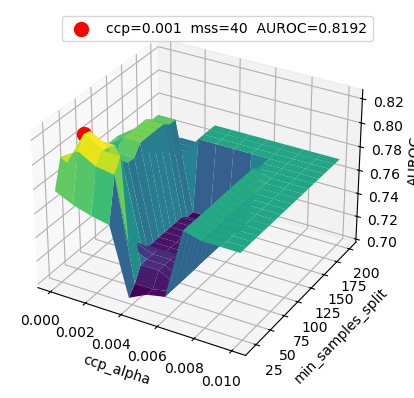

In [9]:
#Q5
pivot = results_df.pivot(index='min_samples_split', columns='ccp_alpha', values='AUROC')

X_mesh, Y_mesh = np.meshgrid(pivot.columns.values, pivot.index.values)


fig, ax  = plt.subplots(subplot_kw={"projection":"3d"})
ax.plot_surface(X_mesh, Y_mesh, pivot.values, cmap=cm.viridis)

# 최적값 점
best = results_df.loc[results_df['AUROC'].idxmax()]
ax.scatter(best['ccp_alpha'], best['min_samples_split'], best['AUROC'],
           color='red', s=100,
           label=f"ccp={best['ccp_alpha']}  mss={int(best['min_samples_split'])}  AUROC={best['AUROC']:.4f}")
ax.legend()

ax.set_xlabel('ccp_alpha')
ax.set_ylabel('min_samples_split')
ax.set_zlabel('AUROC')

plt.show()

In [11]:
print(f"min_samples_split: {int(best['min_samples_split'])}")
print(f"ccp_alpha: {best['ccp_alpha']}")
print(f"AUROC: {best['AUROC']:.4f}")

min_samples_split: 40
ccp_alpha: 0.001
AUROC: 0.8192
